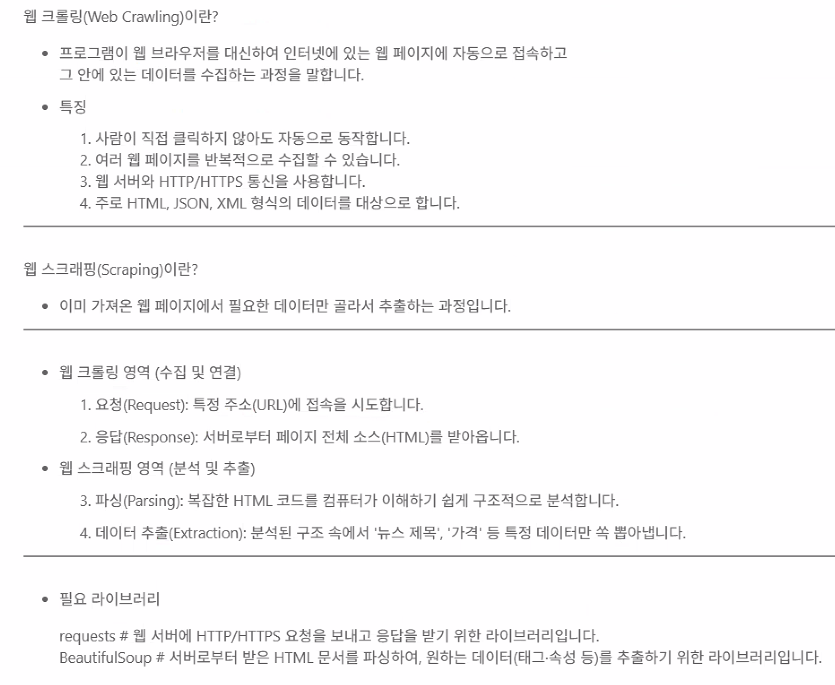

In [4]:
%pip install requests beautifulsoup4

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
from bs4 import BeautifulSoup
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://raw.githubusercontent.com/hiksyksy1234/json/main/index.html"

response = requests.get(url, verify=False)

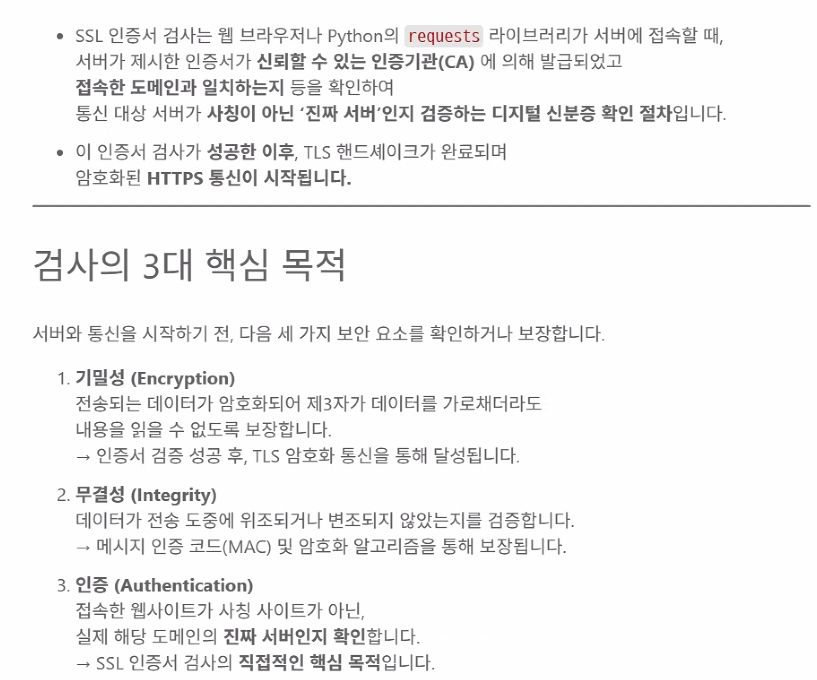

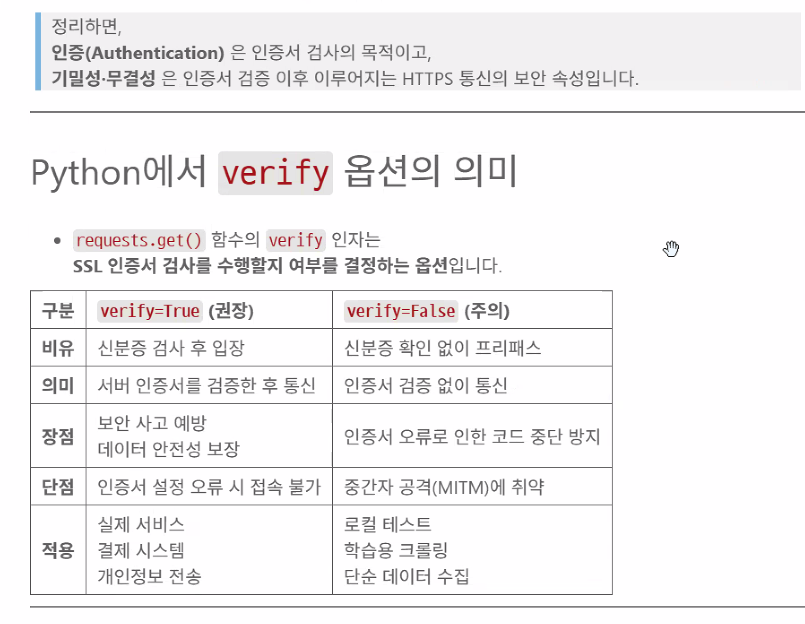

In [3]:
print(response.status_code)

200


In [4]:
print(response.text)

<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <title>나의 크롤링 연습 사이트</title>
</head>
<body>
    <h1>도서 베스트셀러 목록</h1>
    <ul id="book-list">
        <li class="book-item">
            <span class="title">파이썬 데이터 분석 기초</span>
            <span class="price">25,000원</span>
        </li>
        <li class="book-item">
            <span class="title">머신러닝 완벽 가이드</span>
            <span class="price">38,000원</span>
        </li>
        <li class="book-item">
            <span class="title">웹 크롤링 입문</span>
            <span class="price">22,000원</span>
        </li>
    </ul>

    <h1>사용자 후기</h1>
    <div class="review-section">
        <p class="review">강의 내용이 너무 알차서 좋았습니다!</p>
        <p class="review">데이터 분석 입문자에게 강력 추천합니다.</p>
    </div>
</body>
</html>



In [11]:
if response.status_code == 200:

    soup = BeautifulSoup(response.text, 'html.parser')

    title = soup.find('h1').get_text()
    print(f"추출된 제목: {title}")

    book_titles = [t.get_text() for t in soup.select('.title')]
    print(f"도서 목록: {book_titles}")
else:
    print(f"페이지를 불러올 수 없음. 상태 코드: {response.status_code}")

추출된 제목: 도서 베스트셀러 목록
도서 목록: ['파이썬 데이터 분석 기초', '머신러닝 완벽 가이드', '웹 크롤링 입문']


In [10]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd

if response.status_code == 200:
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # 데이터를 담을 빈 리스트 생성
    book_data = []
    
    # soup : HTML 문서 전체
    # soup.select() : HTML 문서 전체에서 클래스 이름이 book-item인 모든 요소를 찾아 리스트 형태로 가져오라는 명령어입니다.
    items = soup.select('.book-item')
    
    for item in items:
        # 도서명과 가격 추출
        name = item.select_one('.title').get_text()      # select_one() : 조건에 맞는 것 중 가장 먼저 나오는 하나만 가져옵니다
        price_text = item.select_one('.price').get_text()
        
        # 분석을 위해 가격에서 '원'과 ','를 제거하고 정수(int)로 변환
        price = int(price_text.replace('원', '').replace(',', ''))
        
        # 딕셔너리 형태로 리스트에 추가
        book_data.append({
            '도서명': name,
            '가격': price
        })
    
    # 2. 리스트를 DataFrame으로 변환
    df = pd.DataFrame(book_data)
    
    # 결과 출력
    print("--- 생성된 DataFrame ---")
    print(df)
    
    # 엑셀 파일로 저장
    df.to_excel("books.xlsx", index=False)
else:
    print(f"페이지를 불러올 수 없습니다. 상태 코드: {response.status_code}")

--- 생성된 DataFrame ---
             도서명     가격
0  파이썬 데이터 분석 기초  25000
1    머신러닝 완벽 가이드  38000
2       웹 크롤링 입문  22000


In [21]:
import pandas as pd

file_path = "books.xlsx"
df = pd.read_excel(file_path)

print("--- 불러온 데이터 확인 ---")
print(df.head())
print('-'*30)

--- 불러온 데이터 확인 ---
             도서명     가격
0  파이썬 데이터 분석 기초  25000
1    머신러닝 완벽 가이드  38000
2       웹 크롤링 입문  22000
------------------------------


In [25]:
avg_price = int(df['가격'].mean())
print(f"전체 도서 평균 가격: {avg_price:,}원\n")

expensive_books = df[df['가격'] >= 30000][['도서명', '가격']]

print(f"--- 3만원 이상 도서 (총 {len(expensive_books)}권) ---")
if not expensive_books.empty:
    print(expensive_books.to_string(index=True))
else:
    print("3만원 이상의 도서가 없습니다.")

# expensive_books.to_excel("expensive_books.xlsx", index=False)

전체 도서 평균 가격: 28,333원

--- 3만원 이상 도서 (총 1권) ---
           도서명     가격
1  머신러닝 완벽 가이드  38000


In [34]:
h1_tags = soup.select('h1')
h1_contents = [tag.get_text() for tag in h1_tags]

print(f"추출된 h1 내용: {h1_contents}")

추출된 h1 내용: ['도서 베스트셀러 목록', '사용자 후기']


In [42]:
reviews = [r.get_text(strip=True) for r in soup.select(".review-section .review")]

print(f"--- 추출된 사용자 후기 ({len(reviews)}건) ---")
for i, review in enumerate(reviews, 1):
    print(f"{i}. {review}")

--- 추출된 사용자 후기 (2건) ---
1. 강의 내용이 너무 알차서 좋았습니다!
2. 데이터 분석 입문자에게 강력 추천합니다.


In [43]:
reviews = pd.DataFrame(reviews, columns=['사용자_후기'])

print("\n--- 데이터프레임 형태 ---")
print(reviews)

reviews.to_excel("user_reviews.xlsx", index=False)


--- 데이터프레임 형태 ---
                   사용자_후기
0    강의 내용이 너무 알차서 좋았습니다!
1  데이터 분석 입문자에게 강력 추천합니다.
